# Online Retail Customer Segmentation using DBSCAN

This project applies DBSCAN clustering to segment e-commerce customers based on their purchasing behavior, using the RFM framework (Recency, Frequency, Monetary). Raw transaction data is transformed into customer level RFM metrics, and DBSCAN is used to automatically discover natural customer segments while identifying customers with unusual buying patterns as noise, without relying on any predefined labels.

In [81]:
#Step 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [82]:
#Step 2
df=pd.read_csv("online_retail.csv")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [83]:
#Step 3
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [84]:
#Step 4
df.dropna(inplace=True)
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [85]:
#Step 5
df.shape

(406829, 8)

In [86]:
#Step 6
#Remove Cancelled Orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
#Verify
df['InvoiceNo'].astype(str).str.startswith('C').sum()




np.int64(0)

In [87]:
#Step 7
df = df.copy()
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [88]:
#Step 8
#Convert into Customer Level cols
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Convert InvoiceDate to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (df['InvoiceDate'].max() - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [89]:
#Step 9
sc=StandardScaler()
rfm_scaled=sc.fit_transform(rfm)

In [90]:
#Step 10
min_samples=5

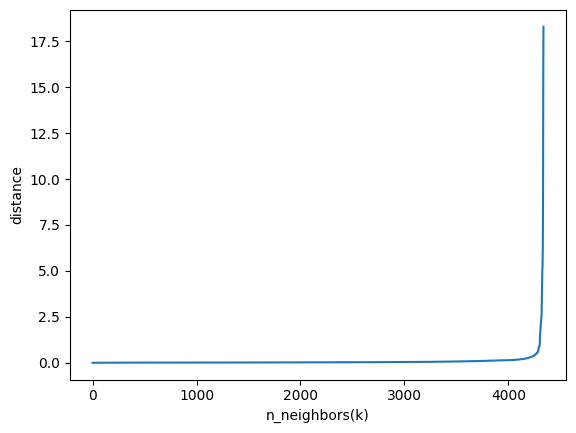

In [91]:
#Step 11
neighbors=NearestNeighbors(n_neighbors=min_samples)
neighbors_fit=neighbors.fit(rfm_scaled)
distances,incides=neighbors_fit.kneighbors(rfm_scaled)
distances=np.sort(distances[:,min_samples-1])
plt.plot(distances)
plt.xlabel("n_neighbors(k)")
plt.ylabel("distance")
plt.show()

In [92]:
#Step 12
for eps_val in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    dbscan = DBSCAN(eps=eps_val, min_samples=5)
    clusters = dbscan.fit_predict(rfm_scaled)
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    noise = (clusters == -1).sum()
    print(f"eps={eps_val}: clusters={n_clusters}, noise={noise}")

eps=0.3: clusters=2, noise=107
eps=0.4: clusters=1, noise=73
eps=0.5: clusters=1, noise=54
eps=0.6: clusters=1, noise=46
eps=0.7: clusters=1, noise=45
eps=0.8: clusters=1, noise=41


In [93]:
#Step 13
dbscan=DBSCAN(eps=0.3,min_samples=5)
clusters=dbscan.fit_predict(rfm_scaled)

In [94]:
#Step 14
rfm['clusters'] = clusters
df = df.merge(rfm[['clusters']], on='CustomerID', how='left')
df['clusters'].value_counts()

,count
clusters,
0,330173
-1,65347
1,2404


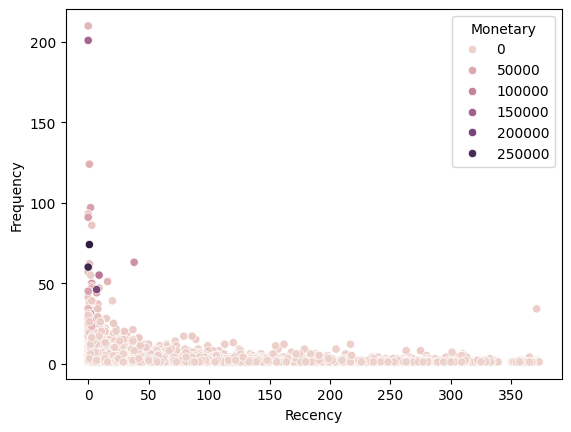

In [95]:
#Step 15
sns.scatterplot(x="Recency", y="Frequency", hue="Monetary", data=rfm)
plt.show()

In [96]:
#Step 16
noise_count = (rfm['clusters'] == -1).sum()
total = len(rfm)
print(f"Noise customers: {noise_count} ({(noise_count/total)*100:.2f}%)")

Noise customers: 107 (2.47%)


In [97]:
#Step 17
rfm.groupby('clusters')[["Recency","Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
clusters,,,
-1,47.411215,30.121495,32218.073551
0,92.760530,3.581401,1266.195294
1,3.166667,29.666667,18855.453333


## Conclusion

This project applied DBSCAN clustering to segment e-commerce customers using the RFM framework, built from raw transaction data. Using a carefully tuned eps value determined through the K-distance graph and empirical testing, DBSCAN identified two distinct customer clusters along with a noise group. Cluster 1 represented the most valuable customers, with very recent purchases, high purchase frequency, and high spending, making them ideal candidates for loyalty rewards. Cluster 0, the largest group, consisted of low frequency, low spending customers with a long time since their last purchase, indicating disengaged or lapsed customers who may benefit from re-engagement campaigns.